In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from flip import data_vector, __flip_dir_path__

flip_base = Path(__flip_dir_path__)
data_path = flip_base / "data"
plt.style.use(data_path / "style.mplstyle")

[ 000000.00 ]: 04-02 03:01  root            WARNING  Install GPy to use the gpmatrix emulator


In [2]:
# Loading data sets

grid = pd.read_parquet(data_path / "data_density.parquet")
data_velocity = pd.read_parquet(data_path / "data_velocity.parquet")
coordinates_velocity = np.array([data_velocity["ra"], data_velocity["dec"], data_velocity["rcom_zobs"]])

# Grid parameters

rcom_max = 150
grid_size = 30
grid_type = "rect"
kind = "ngp"
Nrandom = 10
random_method = "cartesian"

multivariate_kernel="gaussian"

n_subprocess_sampling = 16
Nrandom_sampling = 1_000_000
Nsampling = 100


# Plot parameters

z_min = -rcom_max
dz = grid_size
i = 5
s_point = 600



In [3]:
def plot_grid(grid,
              kind,
              rcom_max,
              z_min,
              dz,
              i,
              s_point,
              title="Density grid", 
              fontsize = 22,
              titlesize = 18,
              legendsize = 20):
    fig, ax = plt.subplots(1,1,figsize=(5.5,5))
    ax = [ax]
    mask = (grid["z"]>z_min + i*dz) & (grid["z"] <=z_min + (i+1)*dz)
    ax[0].set_title(kind + f" {title}",fontsize=titlesize)
    points = ax[0].scatter(grid["x"][mask],grid["y"][mask], c=grid["density"][mask], cmap="plasma",vmax = 1.0, vmin = -1,marker="s", s=s_point)
    ax[0].set_xlim(-rcom_max,rcom_max)
    ax[0].set_ylim(-rcom_max,rcom_max)
    ax[0].set_xlabel("$x$" + r" $[\mathrm{Mpc}$" + r"$\cdot$" + r"$h^{-1}]$",fontsize=fontsize)
    ax[0].set_ylabel("$y$"+ r" $[\mathrm{Mpc}$" + r"$\cdot$" + r"$h^{-1}]$",fontsize=fontsize)
    plt.colorbar(points)

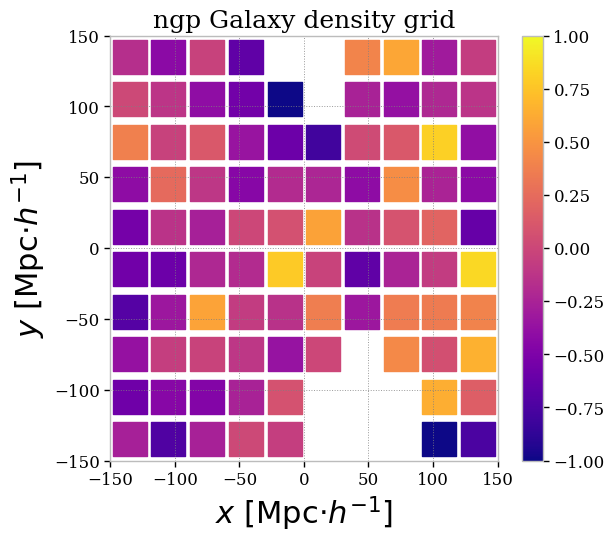

In [4]:
# Density data - Galaxies already gridded

DataDensity = data_vector.DensMesh(grid.to_dict(orient='list'))
plot_grid(DataDensity.data,kind,rcom_max,z_min,dz,i,s_point,
          title="Galaxy density grid")



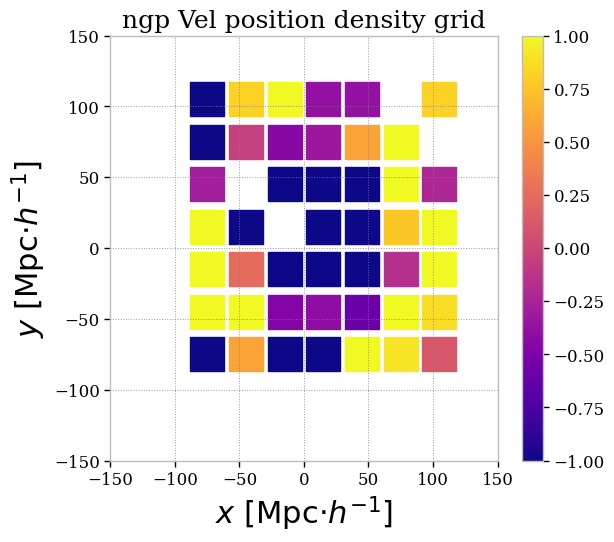

In [5]:
# Density data - Gridding velocity positions

DataDensityVel = data_vector.basic.DensMesh.init_from_catalog(
        coordinates_velocity.T,
        rcom_max,
        grid_size,
        grid_type,
        kind,
        Nrandom=Nrandom,
        random_method=random_method,
        coord_randoms=None,
    )
plot_grid(DataDensityVel.data,kind,rcom_max,z_min,dz,i,s_point,
          title="Vel position density grid")

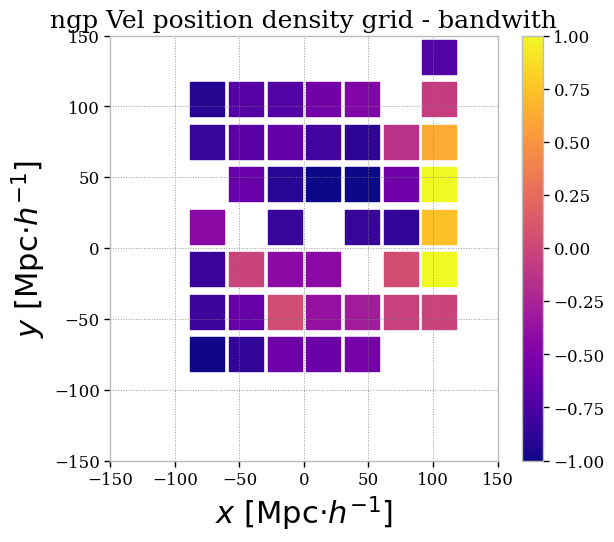

In [6]:

# Density data - Gridding velocity positions with error on position with multivariate gaussian kernel
error_ra = np.radians(1.0)
error_dec = np.radians(1.0)
error_rcom = 10.0
bandwidth = np.array([np.diag([error_ra, error_dec, error_rcom]) for i in range(len(coordinates_velocity[0]))])


DataDensityVel = data_vector.gw_vectors.GWDensMesh.init_from_multivariate_kernel(
        coordinates_velocity.T,
        bandwidth,
        rcom_max,
        grid_size,
        grid_type,
        kind,
        Nrandom=Nrandom,
        random_method=random_method,
        coord_randoms=None,
        kernel=multivariate_kernel,
        cutoff_type=None,
        threshold=1e-5,
    )
plot_grid(DataDensityVel.data,kind,rcom_max,z_min,dz,i,s_point,
          title="Vel position density grid - bandwith")

In [ ]:

# Density data - Gridding velocity positions by sampling with error on position given by position counts

error_ra = np.radians(1.0)
error_dec = np.radians(1.0)
error_rcom = 10.0

N_kernel = 1000
data_position_kernel = []
for k in range(len(coordinates_velocity[0])):
    ra = np.random.normal(coordinates_velocity[0,k], error_ra, size=N_kernel)
    dec = np.random.normal(coordinates_velocity[1,k], error_dec, size=N_kernel)
    rcom = np.random.normal(coordinates_velocity[2,k], error_rcom, size=N_kernel)
    data_position_kernel.append([ra,dec,rcom])
data_position_kernel = np.array(data_position_kernel)


DataDensityVel = data_vector.gw_vectors.GWDensMesh.init_from_kernel_sampling(
        data_position_kernel,
        rcom_max,
        grid_size,
        grid_type,
        kind,
        Nsampling=Nsampling,
        n_subprocess_sampling=n_subprocess_sampling,
        Nrandom=Nrandom_sampling,
        random_method="cartesian_max_coordinates",
        coord_randoms=None,
    )

plot_grid(DataDensityVel.data,kind,rcom_max,z_min,dz,i,s_point,
          title="Vel position density grid - sampling")

/global/common/software/desi/users/adematti/perlmutter/cosmodesiconda/20260321-1.0.0/conda/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
